In [1]:
# === System & OS Utilities ===
import os
import random
import math
import pickle
import sys
import warnings
warnings.filterwarnings("ignore")

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import Model, load_model

from tensorflow.keras.layers import (
    Layer, Conv2D, Dense, Dropout,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Reshape, Multiply, Add, Activation, Concatenate
)
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# === Data Handling ===
import numpy as np
import pandas as pd
import cv2

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# === Scikit-learn ===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

2026-03-18 09:28:29.253945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773826109.610092      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773826109.707053      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773826110.718738      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773826110.718780      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773826110.718782      24 computation_placer.cc:177] computation placer alr

In [2]:
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow version: 2.19.0
Keras version: 3.10.0
NumPy version: 2.0.2
Pandas version: 2.3.3
OpenCV version: 4.12.0
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1


> You need to install specific versions of library given below to work with this notebook

The given command will install the following versions:

* Python: 3.11.11 (as per your system)

* TensorFlow: 2.18.0

* Keras: 3.5.0

* NumPy: 1.26.4

* Pandas: 2.2.3

* OpenCV: 4.6.0.66

* Matplotlib: 3.7.5

* Seaborn: 0.12.2

* Scikit-learn: 1.2.2

In [3]:
#python version 3.11.11
#!python -m pip install tensorflow==2.18.0 keras==3.5.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.6.0.66 matplotlib==3.7.5 seaborn==0.12.2 scikit-learn==1.2.2

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [5]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 50
img_shape=(*IMG_SIZE,3)
labels = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
#labels = ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'UNK', 'VASC']
csv_path = r'../HAM10000_metadata.csv'  
dataset_path = r'/kaggle/input/datasets/faysalshairy/ham1000-aug-resized-organized/HAM10000_organized' # Folder with class subfolders (organized)

In [ ]:
# Read metadata
df_meta = pd.read_csv(csv_path)

# Helper to map image filename back to image_id
def get_image_id(filename):
    name = filename.split("/")[-1].split("\\")[-1] 
    # Remove augmentation suffix if exists
    if "_aug" in name:
        name = name.split("_aug")[0]
    return name.split(".")[0]

In [ ]:
# dataset_path: folder with organized classes
# df_meta: CSV with lesion_id, image_id, dx, etc.

# Build dataframe with image path, class, and lesion_id
image_paths = []
classes = []
lesion_ids = []

for label in os.listdir(dataset_path):
    class_dir = f"{dataset_path}/{label}"
    if not os.path.isdir(class_dir):
        continue
    for img_file in os.listdir(class_dir):
        img_path = f"{class_dir}/{img_file}"
        image_paths.append(img_path)
        classes.append(label)
        img_id = get_image_id(img_file)
        row = df_meta[df_meta['image_id'] == img_id]
        if row.empty:
            raise ValueError(f"{img_id} not found in metadata CSV")
        lesion_ids.append(row.iloc[0]['lesion_id'])

df = pd.DataFrame({
    'Image Path': image_paths,
    'Class': classes,
    'Lesion_ID': lesion_ids
})

# --- Stratified patient-level split ---
train_lesions = []
val_lesions = []
test_lesions = []

random.seed(42)

# Stratify lesions by class
for cls in df['Class'].unique():
    lesions_cls = df[df['Class'] == cls]['Lesion_ID'].unique()
    lesions_cls = list(lesions_cls)
    random.shuffle(lesions_cls)
    
    num_total = len(lesions_cls)
    num_test = max(1, int(num_total * 0.1))   # At least 1 lesion
    num_val = max(1, int(num_total * 0.2))    # ~20% for val
    num_train = num_total - num_test - num_val
    
    train_lesions.extend(lesions_cls[:num_train])
    val_lesions.extend(lesions_cls[num_train:num_train+num_val])
    test_lesions.extend(lesions_cls[num_train+num_val:])

# Convert to sets
train_lesions = set(train_lesions)
val_lesions = set(val_lesions)
test_lesions = set(test_lesions)

# Assign splits
train_dataframe = df[df['Lesion_ID'].isin(train_lesions)].reset_index(drop=True)
validation_dataframe = df[df['Lesion_ID'].isin(val_lesions)].reset_index(drop=True)
test_dataframe = df[df['Lesion_ID'].isin(test_lesions)].reset_index(drop=True)

# Check class balance
# print("Train class distribution:")
# print(train_dataframe['Class'].value_counts())
# print("\nValidation class distribution:")
# print(validation_dataframe['Class'].value_counts())
# print("\nTest class distribution:")
# print(test_dataframe['Class'].value_counts())

print(f"Train size: {len(train_dataframe)}, Val size: {len(validation_dataframe)}, Test size: {len(test_dataframe)}")

Train size: 32854, Validation size: 9387, Test size: 4694


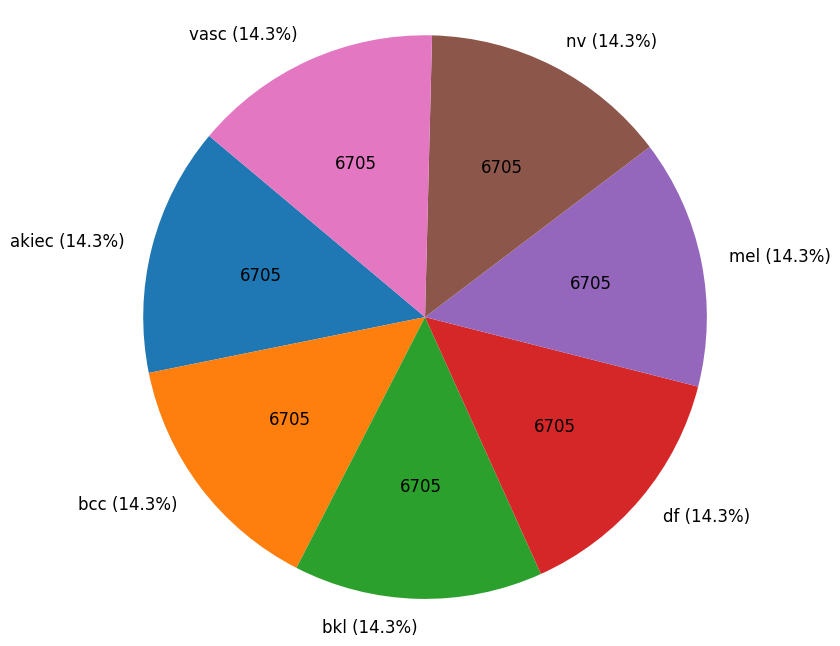

In [8]:
# Count occurrences in each DataFrame
train_counts = train_dataframe['Class'].value_counts()
val_counts = validation_dataframe['Class'].value_counts()
test_counts = test_dataframe['Class'].value_counts()

# Combine and sum the counts
total_counts = train_counts.add(val_counts, fill_value=0)
total_counts = total_counts.add(test_counts, fill_value=0)
total_counts = total_counts.sort_index()

# Prepare labels with percentages
total = total_counts.sum()
labels_with_percent = [f"{label} ({(count/total)*100:.1f}%)" for label, count in zip(total_counts.index, total_counts.values)]

# Define custom autopct function to show raw count
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_counts.values, labels=labels_with_percent, autopct=make_autopct(total_counts.values), startangle=140, textprops={'fontsize': 12})
plt.axis('equal')
plt.show()

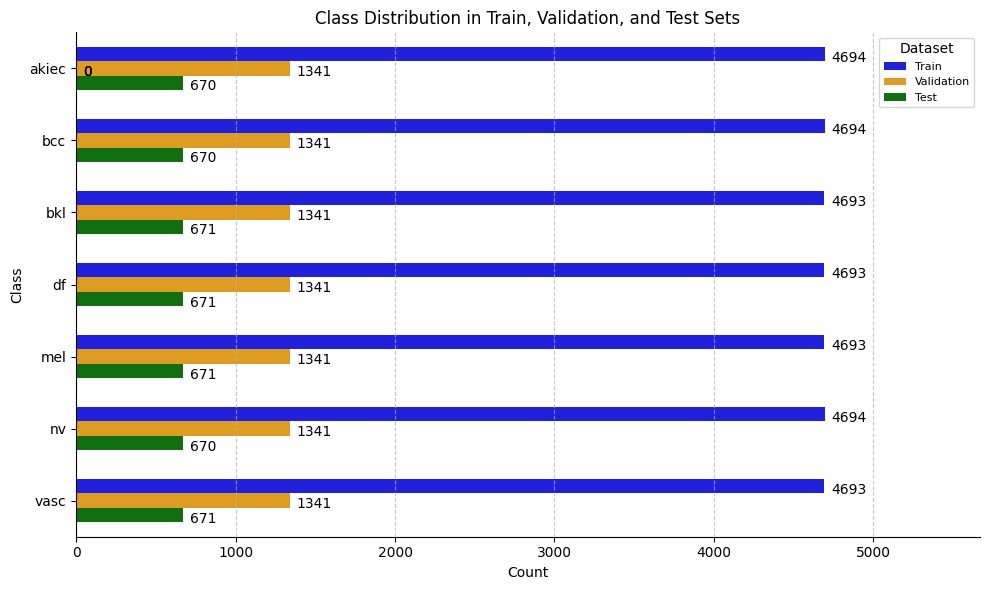

In [9]:
# Count occurrences of each class in train, validation, and test datasets
train_counts = train_dataframe['Class'].value_counts().sort_index()
val_counts = validation_dataframe['Class'].value_counts().sort_index()
test_counts = test_dataframe['Class'].value_counts().sort_index()

# Combine into a DataFrame with the index kept as a column
data_counts = pd.DataFrame({
    'Class': train_counts.index,
    'Train': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values
}).melt(id_vars='Class', var_name='Dataset', value_name='Count')

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Class', x='Count', hue='Dataset', data=data_counts, 
                 palette=['blue', 'orange', 'green'], orient='h', width=0.6)

# Add count labels to the right of the bars with slight downward offset
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.0 + 0.05),  # pushed slightly down
                ha='left', va='center', 
                fontsize=10, color='black', 
                xytext=(5, 0), textcoords='offset points')

# Remove borders (spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Dynamically set the x-axis limits with some extra space on the right
left, right = ax.get_xlim()  # Get current x-limits

# Set the new right limit with a 15% increase
right += (right - left) * 0.15  # Increase right by 15%

# Apply the new limits to the x-axis
ax.set_xlim(left, right)

# Add labels and title
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class Distribution in Train, Validation, and Test Sets")

# Move the legend
plt.legend(title="Dataset", loc='upper right', fontsize=8)

# Add grid only along x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tidy layout
plt.tight_layout()
plt.show()

In [10]:
def preprocess_image(image):
    # Convert image to uint8 if needed (required for CLAHE)
    if image.dtype != np.uint8:
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Convert to LAB color space
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Apply CLAHE to the L-channel (lightness)
    clahe = cv2.createCLAHE(clipLimit=0.01, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])

    # Convert back to RGB
    image_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Apply Min-Max scaling to [0, 1]
    image_clahe = image_clahe.astype(np.float32)
    image_clahe = (image_clahe - np.min(image_clahe)) / (np.ptp(image_clahe) + 1e-8)  # np.ptp = max - min

    return image_clahe

In [11]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Image Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Image Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Image Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, shuffle=False, seed=42)

Found 32854 validated image filenames belonging to 7 classes.
Found 9387 validated image filenames belonging to 7 classes.
Found 4694 validated image filenames belonging to 7 classes.


In [12]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="F1Score")
class F1Score(tf.keras.metrics.Metric):
    """
    Custom Keras metric to compute the F1 Score.
    The F1 score is the harmonic mean of precision and recall.
    """

    def __init__(self, name='f1_score', **kwargs):
        """
        Initializes the F1Score metric. 
        - Uses Keras' Precision and Recall metrics as intermediate steps.
        """
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()  # Precision metric
        self.recall = tf.keras.metrics.Recall()  # Recall metric

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Updates the state of the metric.
        - This method is called during training to update precision and recall.
        - The precision and recall states are updated based on true and predicted values.
        """
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        """
        Computes and returns the F1 score.
        - F1 score is calculated as the harmonic mean of precision and recall.
        - Prevents division by zero by adding a small epsilon value to the denominator.
        """
        p = self.precision.result()  # Get precision value
        r = self.recall.result()  # Get recall value
        return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())  # Calculate F1 score

    def reset_states(self):
        """
        Resets the states of the precision and recall metrics.
        - This is called at the beginning of each epoch.
        """
        self.precision.reset_states()  # Reset precision state
        self.recall.reset_states()  # Reset recall state


In [13]:
class RestoreBestValidationModel(Callback):
    """
    Custom Keras Callback to restore model weights from the best epoch based on validation accuracy.
    - Tracks the best validation accuracy during training.
    - Restores the model weights from the epoch with the best validation accuracy when training finishes.
    """
    
    def __init__(self):
        super(RestoreBestValidationModel, self).__init__()
        # Initialize best validation accuracy, epoch, and weights to track the best model
        self.best_val_acc = -1
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        """
        Callback function executed at the end of each epoch.
        - Compares the current validation accuracy with the best validation accuracy.
        - If the current validation accuracy is higher or tied but at a later epoch, updates the best model weights.
        """
        # Get validation accuracy from logs
        val_acc = logs.get('val_accuracy')
        
        if val_acc is not None:
            # Update the best validation accuracy and weights if the current one is better or at a later epoch
            if val_acc > self.best_val_acc or (val_acc == self.best_val_acc and epoch > self.best_epoch):
                self.best_val_acc = val_acc
                self.best_epoch = epoch
                self.best_weights = self.model.get_weights()  # Store the model's weights
                print(f"Model weights updated at epoch {epoch + 1} with val_accuracy: {val_acc:.4f}")

    def on_train_end(self, logs=None):
        """
        Callback function executed at the end of training.
        - Restores the model weights from the epoch with the best validation accuracy.
        """
        # If we found a better model during training, restore the best weights
        if self.best_weights is not None:
            print(f"Restoring model weights from best epoch {self.best_epoch + 1} with val_accuracy: {self.best_val_acc:.4f}")
            self.model.set_weights(self.best_weights)  # Set the weights back to the best model's weights

# Instantiate the callback
restore_best = RestoreBestValidationModel()


In [14]:
# Channel Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="ChannelAttention")
class ChannelAttention(Layer):
    """
    Channel Attention Block (CA) that computes channel-wise attention.
    
    Args:
        reduction: The factor for reducing the number of channels in the intermediate layer.
    """
    def __init__(self, reduction=16, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        """
        Build the dense layers for the Channel Attention mechanism.
        - `shared_dense_one`: reduces channel dimensions.
        - `shared_dense_two`: restores the original channel dimensions.
        """
        channel = input_shape[-1]  # Number of channels in the input tensor
        self.shared_dense_one = Dense(channel // self.reduction, activation='relu', kernel_initializer='he_normal', use_bias=True)
        self.shared_dense_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    def call(self, inputs):
        """
        Apply the Channel Attention mechanism:
        - Global Average Pooling (avg_pool) and Global Max Pooling (max_pool)
        - Process each through a set of shared dense layers.
        - Combine both attentions and apply a sigmoid function to get the attention weights.
        """
        # Global average and max pooling
        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)

        # Apply shared dense layers for both average and max pooled features
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)

        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)

        # Combine both attention signals and apply sigmoid activation
        attention = Add()([avg_pool, max_pool])
        attention = Activation('sigmoid')(attention)

        # Reshape the attention to match the input dimensions and apply multiplication
        attention = Reshape((1, 1, -1))(attention)
        return Multiply()([inputs, attention])

# Spatial Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(Layer):
    """
    Spatial Attention Block (SA) that computes spatial attention across channels.
    """
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        # 2D convolution for spatial attention with a kernel size of 7x7 and sigmoid activation
        self.conv2d = Conv2D(filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid')

    def call(self, inputs):
        """
        Apply the Spatial Attention mechanism:
        - Apply both average and max pooling across the channel axis to extract spatial features.
        - Concatenate the two features and apply convolution to get spatial attention.
        """
        # Apply global average and max pooling along the channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)

        # Concatenate both pooled features
        concat = Concatenate(axis=-1)([avg_pool, max_pool])

        # Apply convolution to compute spatial attention map
        attention = self.conv2d(concat)

        # Multiply the attention map with the input to highlight important spatial features
        return Multiply()([inputs, attention])

# Full CBAM Block
def cbam_block(inputs, reduction=16):
    """
    CBAM (Convolutional Block Attention Module) that sequentially applies
    Channel Attention and Spatial Attention blocks.

    Args:
        inputs: Input tensor to the CBAM block.
        reduction: The factor for reducing the channel dimension in the Channel Attention block.
    
    Returns:
        The output tensor after applying both attention mechanisms.
    """
    # Apply Channel Attention followed by Spatial Attention
    x = ChannelAttention(reduction)(inputs)
    x = SpatialAttention()(x)
    return x

# Focal Loss
@tf.keras.utils.register_keras_serializable(package="Custom")
class FocalLoss(tf.keras.losses.Loss):

    def __init__(
        self,
        gamma=2.0,
        alpha=0.25,
        reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
        name="focal_loss",
    ):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        # Avoid numerical instability
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0)

        # Categorical cross entropy
        ce = -y_true * tf.math.log(y_pred)

        # Compute modulating factor
        p_t = y_true * y_pred
        modulating_factor = tf.pow(1.0 - p_t, self.gamma)

        # Apply alpha weighting
        alpha_factor = y_true * self.alpha

        loss = alpha_factor * modulating_factor * ce

        return tf.reduce_sum(loss, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "gamma": self.gamma,
            "alpha": self.alpha,
        })
        return config


In [15]:
# Base model
# Using Xception as the base model with pre-trained ImageNet weights.
# Excluding the top (classification) layer to use the base for feature extraction.
base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                            input_shape=img_shape, pooling=None)

# Attention after base model feature map
# Applying the CBAM block (Channel Attention + Spatial Attention) to the output of the base model.
#x = cbam_block(base_model.output)

# Continue classification
# Apply Global Average Pooling to reduce the spatial dimensions (height & width) to a single value per channel.
x = GlobalAveragePooling2D()(base_model.output)  

# Dropout layer to reduce overfitting during training by randomly setting 30% of the input units to 0.
x = Dropout(0.30)(x)

# Dense layer with 128 units and ReLU activation. 
# L1 and L2 regularization applied to the weights to prevent overfitting.
x = Dense(128, activation='relu', 
          kernel_regularizer=L1L2(l1=1e-4, 
                                  l2=1e-3))(x)

# Dropout layer to further prevent overfitting with 25% of input units being dropped.
x = Dropout(0.25)(x)

# Final output layer with the number of classes equal to the length of the labels.
# Softmax activation for multi-class classification.
x = Dense(len(labels), activation='softmax')(x)

# Define the complete model
model = Model(inputs = base_model.input, outputs = x)

# Freeze initial layers
# Set the base model layers to be non-trainable after freezing the first 50 layers.
# base_model.trainable = True
# for layer in base_model.layers[:50]:
#     layer.trainable = False

# Compile the model
# Adamax optimizer is used with a learning rate of 0.001.
# Categorical cross-entropy loss is used for multi-class classification.
# Additional metrics: accuracy, precision, recall, F1 score, and AUC (Area Under the Curve).
model.compile(Adamax(learning_rate=0.001),
               loss=FocalLoss(gamma=2.0, alpha=0.25),
               metrics=['accuracy', 
                        Precision(name='precision'), 
                        Recall(name='recall'),
                        F1Score(),
                        AUC(name='auc')])

# Print the model summary to check the architecture.
model.summary()

I0000 00:00:1773826241.209952      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 4,172,419 (15.92 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [16]:
history = model.fit(train_data,
                 epochs=EPOCH,             
                 validation_data=validation_data,
                 callbacks=[restore_best],
                 shuffle= False)

Epoch 1/50


I0000 00:00:1773826277.872017      68 service.cc:152] XLA service 0x7aa5541216d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773826277.872065      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773826282.755011      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-18 09:31:35.049577: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 09:31:35.237336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 09:31:35.704391: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

1026/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.6363 - auc: 0.9134 - f1_score: 0.5553 - loss: 0.6566 - precision: 0.8333 - recall: 0.4300

2026-03-18 09:41:03.268408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 09:41:03.454446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 09:41:03.904085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 09:41:04.112365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 09:41:04.468319: E external/local_xla/xla/stream_

1027/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.6364 - auc: 0.9135 - f1_score: 0.5554 - loss: 0.6564 - precision: 0.8333 - recall: 0.4301Model weights updated at epoch 1 with val_accuracy: 0.1364
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 710s 622ms/step - accuracy: 0.6365 - auc: 0.9135 - f1_score: 0.5555 - loss: 0.6562 - precision: 0.8334 - recall: 0.4303 - val_accuracy: 0.1364 - val_auc: 0.4995 - val_f1_score: 0.0974 - val_loss: 1.8558 - val_precision: 0.1257 - val_recall: 0.0795
Epoch 2/50
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8517 - auc: 0.9857 - f1_score: 0.8307 - loss: 0.1177 - precision: 0.9148 - recall: 0.7609Model weights updated at epoch 2 with val_accuracy: 0.1446
1027/1027 ━━━━━━━━━━━━━━━━━━━━ 496s 483ms/step - accuracy: 0.8517 - auc: 0.9857 - f1_score: 0.8307 - loss: 0.1177 - precision: 0.9148 - recall: 0.7609 - val_accuracy: 0.1446 - val_auc: 0.5009 - val_f1_score: 0.1446 - val_loss: 3.4641 - val_precision: 0.1446 - val_recall: 0.1446
Epoch 3/50
1027/1

In [17]:
model.save("VGG16.keras") 

In [18]:
model = load_model('VGG16.keras')  

In [19]:
# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [20]:
# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [21]:
epochs = range(1, len(history['loss']) + 1)

# Training and validation metrics
tr_loss = history['loss']
val_loss = history['val_loss']
tr_acc = history['accuracy']
val_acc = history['val_accuracy']
tr_precision = history['precision']
val_precision = history['val_precision']
tr_auc = history['auc']
val_auc = history['val_auc']
tr_f1 = history['f1_score']
val_f1 = history['val_f1_score']

In [22]:
def print_best_metrics(metric_name, train, val):
    best_epoch = np.argmax(val) + 1
    print(f"📌 Best {metric_name} at epoch {best_epoch}:")
    print(f"   - Train {metric_name}: {abs(train[best_epoch - 1]):.4f}")
    print(f"   - Val {metric_name}:   {abs(val[best_epoch - 1]):.4f}\n")

print_best_metrics("Accuracy", tr_acc, val_acc)
print_best_metrics("Precision", tr_precision, val_precision)
print_best_metrics("AUC", tr_auc, val_auc)
print_best_metrics("F1 Score", tr_f1, val_f1)
print_best_metrics("Loss", [-x for x in tr_loss], [-x for x in val_loss])  # inverted for max-based search

📌 Best Accuracy at epoch 20:
   - Train Accuracy: 0.9903
   - Val Accuracy:   0.6864

📌 Best Precision at epoch 5:
   - Train Precision: 0.9611
   - Val Precision:   0.7826

📌 Best AUC at epoch 20:
   - Train AUC: 0.9999
   - Val AUC:   0.9320

📌 Best F1 Score at epoch 20:
   - Train F1 Score: 0.9892
   - Val F1 Score:   0.6931

📌 Best Loss at epoch 20:
   - Train Loss: 0.0099
   - Val Loss:   0.1693



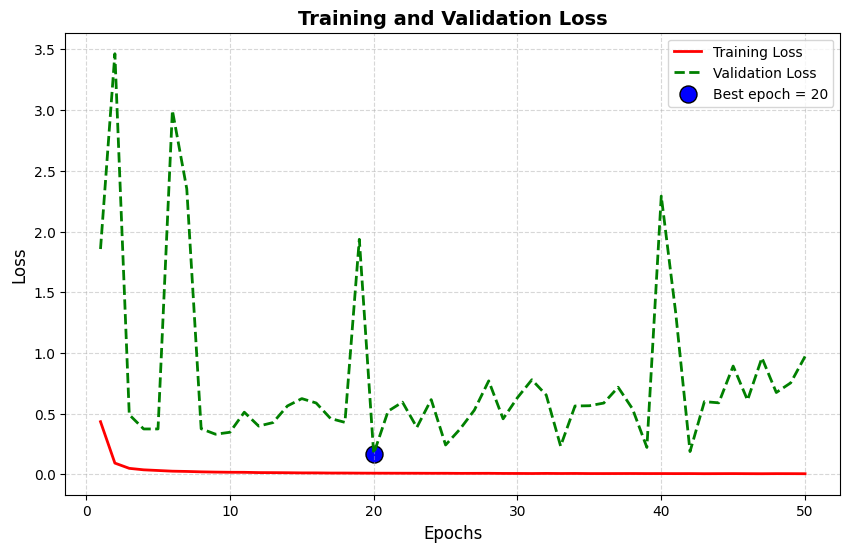

In [23]:
best_epoch_loss = np.argmin(val_loss)
best_val_loss = val_loss[best_epoch_loss]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_loss, color='red', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, color='green', label='Validation Loss', linestyle='--', linewidth=2)
plt.scatter(best_epoch_loss + 1, best_val_loss, s=150, c='blue',
            label=f'Best epoch = {best_epoch_loss + 1}', edgecolors='black')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

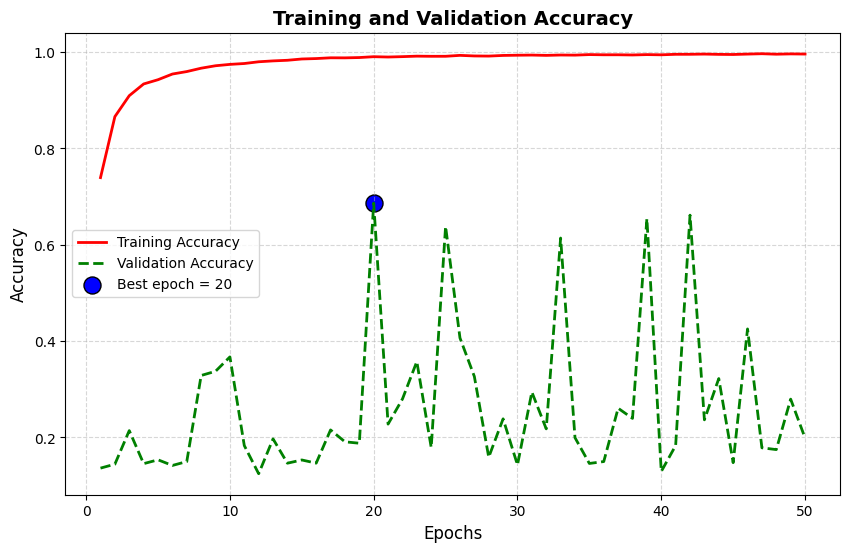

In [24]:
best_epoch_acc = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch_acc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, color='red', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='green', label='Validation Accuracy', linestyle='--', linewidth=2)
plt.scatter(best_epoch_acc + 1, best_val_acc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_acc + 1}', edgecolors='black')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


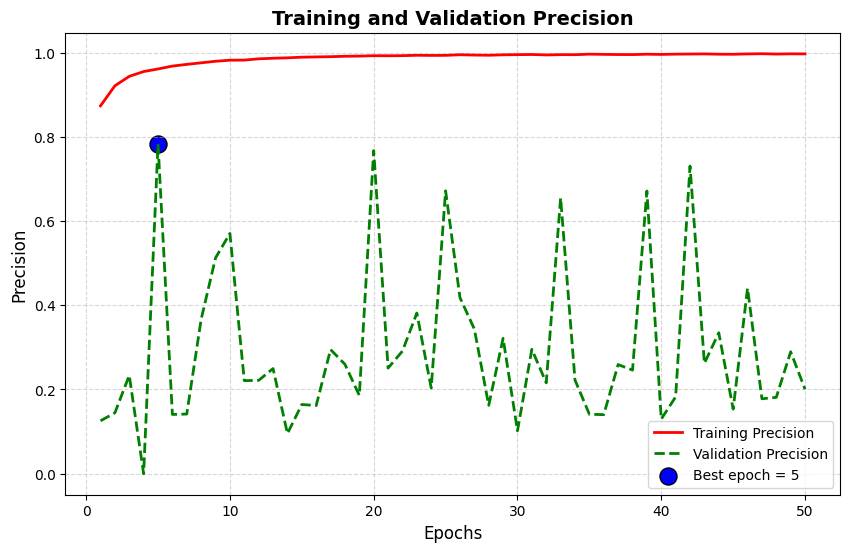

In [25]:
best_epoch_prec = np.argmax(val_precision)
best_val_prec = val_precision[best_epoch_prec]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_precision, color='red', label='Training Precision', linewidth=2)
plt.plot(epochs, val_precision, color='green', label='Validation Precision', linestyle='--', linewidth=2)
plt.scatter(best_epoch_prec + 1, best_val_prec, s=150, c='blue',
            label=f'Best epoch = {best_epoch_prec + 1}', edgecolors='black')
plt.title('Training and Validation Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


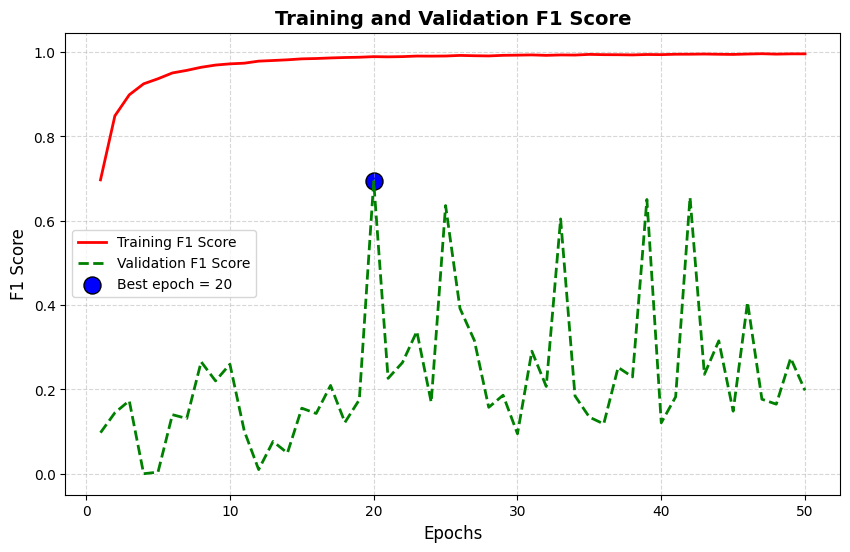

In [26]:
best_epoch_f1 = np.argmax(val_f1)
best_val_f1 = val_f1[best_epoch_f1]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_f1, color='red', label='Training F1 Score', linewidth=2)
plt.plot(epochs, val_f1, color='green', label='Validation F1 Score', linestyle='--', linewidth=2)
plt.scatter(best_epoch_f1 + 1, best_val_f1, s=150, c='blue',
            label=f'Best epoch = {best_epoch_f1 + 1}', edgecolors='black')
plt.title('Training and Validation F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

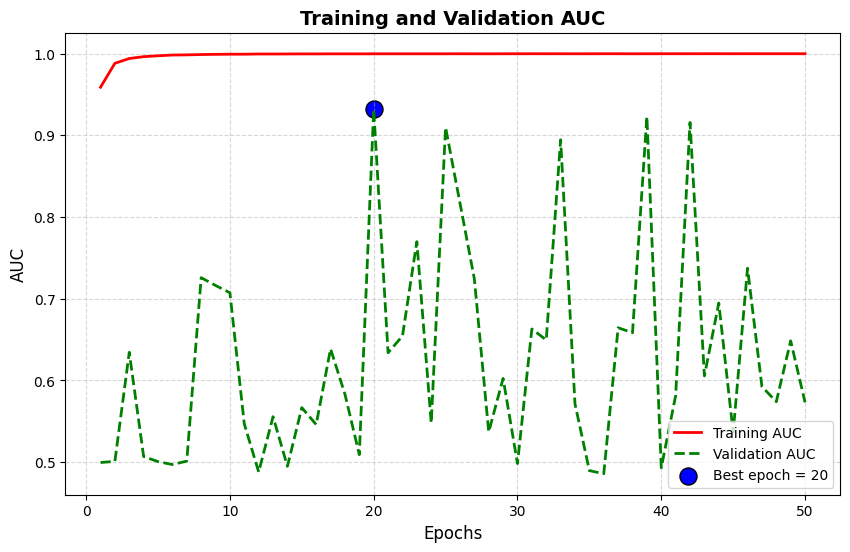

In [27]:
best_epoch_auc = np.argmax(val_auc)
best_val_auc = val_auc[best_epoch_auc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_auc, color='red', label='Training AUC', linewidth=2)
plt.plot(epochs, val_auc, color='green', label='Validation AUC', linestyle='--', linewidth=2)
plt.scatter(best_epoch_auc + 1, best_val_auc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_auc + 1}', edgecolors='black')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [28]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

def evaluate_model(model, test_data, labels, model_name, test_dataframe, batch_size=BATCH_SIZE):
    """
    Evaluate a trained Keras model using a test data generator.

    Args:
        model (Model): Trained Keras model.
        test_data (Iterator): A Keras data generator for testing.
        labels (List[str]): Class label names.
        model_name (str): Name of the model (for display).
        test_dataframe (pd.DataFrame): DataFrame with test samples (for step calculation).
        batch_size (int): Batch size used in the test_data generator.

    Returns:
        Tuple[dict, dict]: 
            - Dictionary containing accuracy, precision, recall, F1 score, AUC, specificity, balanced accuracy.
            - Dictionary of AUC curve data {class_label: (fpr, tpr)} for ROC plotting.
    """

    # Calculate steps needed for full evaluation
    steps = math.ceil(len(test_dataframe) / batch_size)

    y_true = []
    y_pred = []
    y_probs = []

    # Loop through batches and collect predictions and true labels
    for _ in tqdm(range(steps), desc=f"Evaluating {model_name}"):
        images, labels_batch = next(test_data)

        preds = model.predict(images, verbose=0)            # Predicted probabilities
        y_probs.extend(preds)                               # Save for AUC

        y_pred.extend(np.argmax(preds, axis=-1))            # Predicted class indices
        y_true.extend(np.argmax(labels_batch, axis=-1))     # True class indices

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    # --- Basic performance metrics ---
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # --- Specificity calculation ---
    # For multi-class, specificity per class = TN / (TN + FP)
    cm = confusion_matrix(y_true, y_pred)
    TN = []
    FP = []
    for i in range(len(labels)):
        TP = cm[i, i]
        FP_i = cm[:, i].sum() - TP
        FN_i = cm[i, :].sum() - TP
        TN_i = cm.sum() - (TP + FP_i + FN_i)
        TN.append(TN_i)
        FP.append(FP_i)
    specificity_per_class = np.array(TN) / (np.array(TN) + np.array(FP) + 1e-7)
    specificity = np.mean(specificity_per_class)  # average specificity across classes

    # --- AUC ---
    try:
        auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc = float('nan')

    # Generate classification report
    report = classification_report(y_true, y_pred, target_names=labels)

    # Print summary metrics
    print(f"--- {model_name} ---")
    print(f"Accuracy         : {accuracy:.4f}")
    print(f"Precision        : {precision:.4f}")
    print(f"Recall           : {recall:.4f}")
    print(f"F1 Score         : {f1:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Specificity      : {specificity:.4f}")
    print(f"AUC              : {auc:.4f}\n")
    print("Classification Report:\n")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        annot_kws={'size': 14}, cbar=True, linewidths=0.5, linecolor='gray',
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, rotation=45 if len(labels) > 10 else 0)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Compute ROC curve data per class
    auc_curve_data = {}
    try:
        for i, label in enumerate(labels):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
            auc_curve_data[label] = (fpr, tpr)
    except Exception:
        auc_curve_data = {}

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "balanced_accuracy": balanced_acc,
        "specificity": specificity,
        "auc": auc
    }, auc_curve_data

Evaluating VGG16: 100%|██████████| 147/147 [01:23<00:00,  1.76it/s]


--- VGG16 ---
Accuracy         : 0.6734
Precision        : 0.7746
Recall           : 0.6735
F1 Score         : 0.6885
Balanced Accuracy: 0.6735
Specificity      : 0.9456
AUC              : 0.9409

Classification Report:

              precision    recall  f1-score   support

       akiec       0.87      0.56      0.68       670
         bcc       0.77      0.72      0.74       670
         bkl       0.63      0.62      0.63       671
          df       0.98      0.61      0.75       671
         mel       0.81      0.46      0.59       671
          nv       0.39      0.95      0.55       670
        vasc       0.98      0.80      0.88       671

    accuracy                           0.67      4694
   macro avg       0.77      0.67      0.69      4694
weighted avg       0.77      0.67      0.69      4694



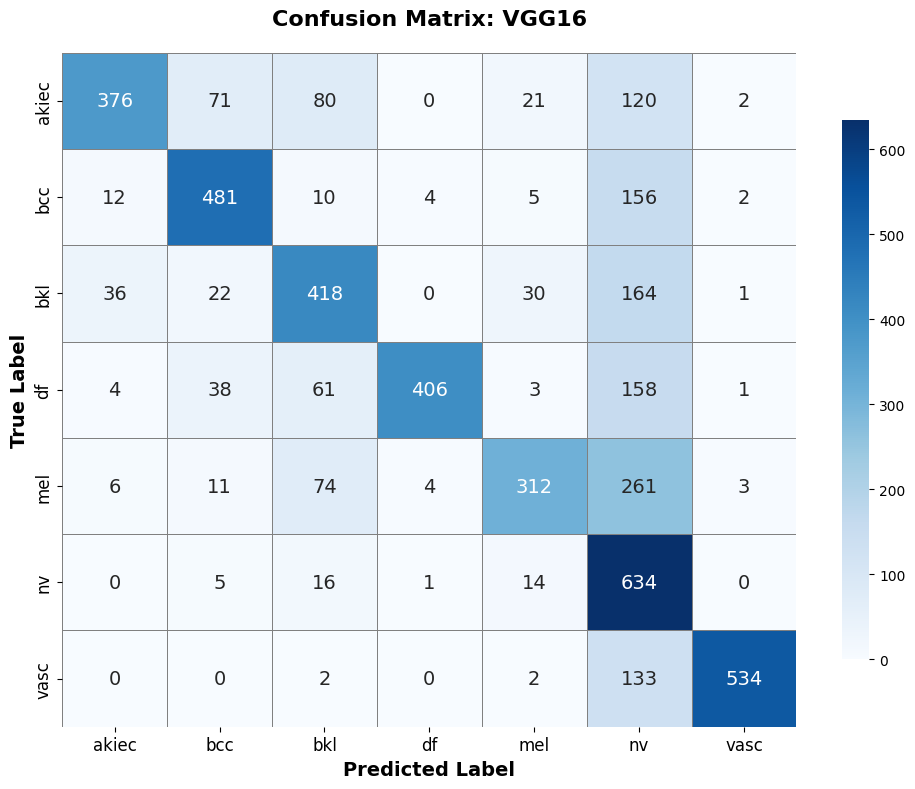

In [29]:
results, auc_curve_data = evaluate_model(model, test_data, labels, "VGG16", test_dataframe)

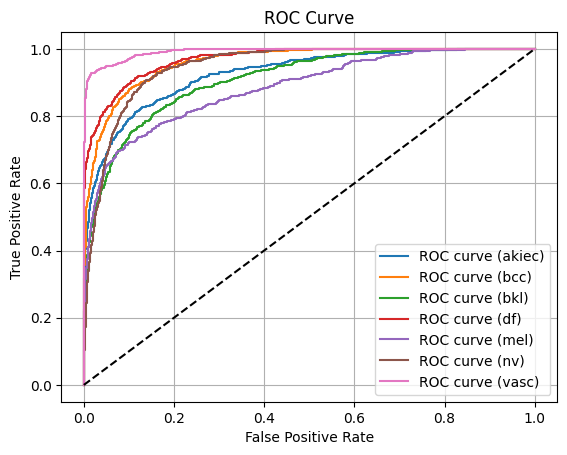

In [30]:
# Plotting the ROC curve
for label, (fpr, tpr) in auc_curve_data.items():
    plt.plot(fpr, tpr, label=f'ROC curve ({label})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()